In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [70]:
iris = pd.read_csv('../datasets/iris.csv')

In [71]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [72]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [73]:
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [74]:
iris["species"].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [75]:
iris["target"] = np.where(iris["species"]=="setosa", 0, np.where(iris["species"]=="versicolor", 1, 2))

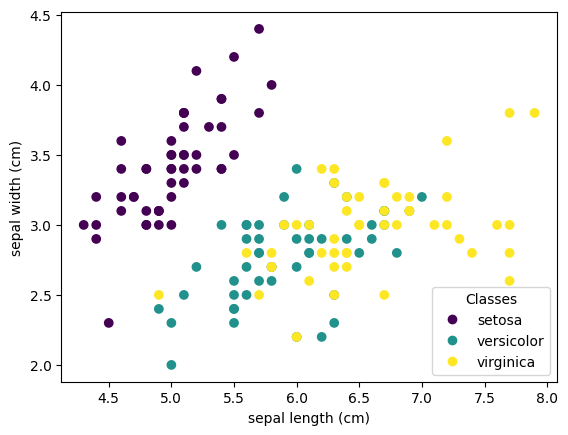

In [76]:
fig, ax = plt.subplots()
scatter = ax.scatter(iris["sepal_length"], iris["sepal_width"], c=iris["target"])
ax.set(xlabel="sepal length (cm)", ylabel='sepal width (cm)')
ax.legend(scatter.legend_elements()[0], iris["species"].unique(), loc="lower right", title="Classes")

In [81]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species,target
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


1. Calculate mean, median, std, min and max for each numeric column

In [92]:

result3 = iris.agg(stats).T
print("Method 3: Custom agg")
print(result3)

KeyError: "Column(s) ['25%', '50%', '75%', 'count', 'max', 'mean', 'min', 'std'] do not exist"

In [103]:
numeric_columns = iris.drop('target', axis=1).select_dtypes(np.number).columns.tolist()
def range_(x):
    return x.max() - x.min()
funcs = ['count', 'mean', 'std', 'min', 'max', range_, 'median'] 
stats = {col_name: funcs for col_name in numeric_columns}

iris.agg(stats).round(2)


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
max,7.90,4.40,6.90,2.50
range_,3.60,2.40,5.90,2.40
median,5.80,3.00,4.35,1.30


2. Group by species and find average of each feature

In [105]:
iris.drop('target', axis=1).groupby(['species']).agg('mean')

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.418,1.464,0.244
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


3. Count number of samples per species

In [112]:
iris.drop('target', axis=1).groupby(['species'])['species'].count().reset_index(name='count')


,species,count
0,setosa,50
1,versicolor,50
2,virginica,50


4. Count number of duplicates and check if data has any duplicates

In [122]:
iris.apply(lambda x: x.duplicated(keep=False).sum())

sepal_length    141
sepal_width     145
petal_length    140
petal_width     148
species         150
target          150
dtype: int64

In [123]:
iris.nunique() #distinct

sepal_length    35
sepal_width     23
petal_length    43
petal_width     22
species          3
target           3
dtype: int64

In [137]:
iris['petal_width'].unique()

array([0.2, 0.4, 0.3, 0.1, 0.5, 0.6, 1.4, 1.5, 1.3, 1.6, 1. , 1.1, 1.8,
       1.2, 1.7, 2.5, 1.9, 2.1, 2.2, 2. , 2.4, 2.3])

In [136]:
counts_ = iris['petal_width'].value_counts()
counts_[counts_==1].count() #unique

2

5. Find flowers with petal_length > 4.0 and sepal_width < 3.0

In [140]:
mask = (iris['petal_length'] > 4.0) & (iris['sepal_width'] < 3.0)
iris[mask].head()

,sepal_length,sepal_width,petal_length,petal_width,species,target
54,6.5,2.8,4.6,1.5,versicolor,1
55,5.7,2.8,4.5,1.3,versicolor,1
58,6.6,2.9,4.6,1.3,versicolor,1
63,6.1,2.9,4.7,1.4,versicolor,1
67,5.8,2.7,4.1,1.0,versicolor,1


6. Find top 5 flowers with largest sepal_width

In [141]:
iris.nlargest(5, 'sepal_width')

,sepal_length,sepal_width,petal_length,petal_width,species,target
15,5.7,4.4,1.5,0.4,setosa,0
33,5.5,4.2,1.4,0.2,setosa,0
32,5.2,4.1,1.5,0.1,setosa,0
14,5.8,4.0,1.2,0.2,setosa,0
5,5.4,3.9,1.7,0.4,setosa,0


In [143]:
iris.sort_values(by='sepal_width', ascending=False).head()

,sepal_length,sepal_width,petal_length,petal_width,species,target
15,5.7,4.4,1.5,0.4,setosa,0
33,5.5,4.2,1.4,0.2,setosa,0
32,5.2,4.1,1.5,0.1,setosa,0
14,5.8,4.0,1.2,0.2,setosa,0
16,5.4,3.9,1.3,0.4,setosa,0


7. Rank flowers by petal_width within each species

In [151]:
iris['rank'] = iris.groupby(['species'])['petal_width'].rank(method='dense')
iris.sort_values(by=['species', 'petal_width'])

,sepal_length,sepal_width,petal_length,petal_width,species,target,rank
9,4.9,3.1,1.5,0.1,setosa,0,1.0
12,4.8,3.0,1.4,0.1,setosa,0,1.0
13,4.3,3.0,1.1,0.1,setosa,0,1.0
32,5.2,4.1,1.5,0.1,setosa,0,1.0
34,4.9,3.1,1.5,0.1,setosa,0,1.0
...,...,...,...,...,...,...,...
136,6.3,3.4,5.6,2.4,virginica,2,11.0
140,6.7,3.1,5.6,2.4,virginica,2,11.0
100,6.3,3.3,6.0,2.5,virginica,2,12.0
109,7.2,3.6,6.1,2.5,virginica,2,12.0


8. Create size categories based on petal_length

In [160]:
bins = [0, 2, 4, 6, 8]
labels = ['very small', 'small', 'medium', 'large']

iris['category'] = pd.cut(iris['petal_length'], bins=bins, labels=labels)
iris

,sepal_length,sepal_width,petal_length,petal_width,species,target,rank,category
0,5.1,3.5,1.4,0.2,setosa,0,2.0,very small
1,4.9,3.0,1.4,0.2,setosa,0,2.0,very small
2,4.7,3.2,1.3,0.2,setosa,0,2.0,very small
3,4.6,3.1,1.5,0.2,setosa,0,2.0,very small
4,5.0,3.6,1.4,0.2,setosa,0,2.0,very small
...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,2,10.0,medium
146,6.3,2.5,5.0,1.9,virginica,2,6.0,medium
147,6.5,3.0,5.2,2.0,virginica,2,7.0,medium
148,6.2,3.4,5.4,2.3,virginica,2,10.0,medium


9. Find species with largest average sepal length

In [175]:
avg_sepal_per_species = iris.groupby(['species']).agg(mean=('sepal_length', 'mean'))
largest_avg_sepal_species = avg_sepal_per_species.idxmax().iloc[0]
largest_avg_sepal_value = avg_sepal_per_species.max().iloc[0]
largest_avg_sepal_species, largest_avg_sepal_value

('virginica', 6.587999999999999)

In [189]:
avg_sepal_per_species = iris.groupby(['species']).agg(mean=('sepal_length', 'mean')).sort_values(by='mean', ascending=False)
avg_sepal_per_species.index[0], avg_sepal_per_species.values[0]

('virginica', array([6.588]))

10. Calculate correlation between all numeric features

In [199]:
corr_ = iris.drop(['target', 'rank'], axis=1).select_dtypes(np.number).corr()
corr_

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


11. Which two features are most correlated?

In [214]:
mask = np.triu(corr_, k=1).astype('bool')
corr_.where(mask).stack().max(), corr_.where(mask).stack().idxmax()

(0.9627570970509662, ('petal_length', 'petal_width'))

In [246]:
unstack_corr = corr_.unstack().reset_index()
unstack_corr = unstack_corr[unstack_corr[0]!=1]
unstack_corr.sort_values(by=0, ascending=False).head(1)

,level_0,level_1,0
11,petal_length,petal_width,0.962757


In [260]:
unstack_corr = corr_.unstack()
unstack_corr[unstack_corr.values!=1].max(), unstack_corr[unstack_corr.values!=1].idxmax()

(0.9627570970509662, ('petal_length', 'petal_width'))

12. Find the species with most variation in petal_width (highest std)

In [263]:
std_petal_width = iris.groupby(['species'])['petal_width'].std()
std_petal_width.idxmax(), std_petal_width.max()

virginica 0.27465005563666745


,sepal_length,sepal_width,petal_length,petal_width,species,target,rank,category
5,5.4,3.9,1.7,0.4,setosa,0,4.0,very small
6,4.6,3.4,1.4,0.3,setosa,0,3.0,very small
15,5.7,4.4,1.5,0.4,setosa,0,4.0,very small
16,5.4,3.9,1.3,0.4,setosa,0,4.0,very small
17,5.1,3.5,1.4,0.3,setosa,0,3.0,very small
...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,2,10.0,medium
146,6.3,2.5,5.0,1.9,virginica,2,6.0,medium
147,6.5,3.0,5.2,2.0,virginica,2,7.0,medium
148,6.2,3.4,5.4,2.3,virginica,2,10.0,medium


13. Calculate IQR for each feature by species

In [270]:
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)
iris.groupby(['species'])[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].apply(iqr)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,0.400,0.550,0.175,0.1
versicolor,0.700,0.475,0.600,0.3
virginica,0.675,0.375,0.775,0.5


14. Which species has the largest sepal length variability?

In [272]:
iris.groupby('species')['sepal_length'].std().sort_values(ascending=False).head(1)

species
virginica    0.63588
Name: sepal_length, dtype: float64

15. Find flowers that have petal_length > species average

In [277]:
iris['avg'] = iris.groupby(['species'])['petal_length'].transform('mean')
iris[iris['petal_length']>=iris['avg']]

,sepal_length,sepal_width,petal_length,petal_width,species,target,rank,category,avg
3,4.6,3.1,1.5,0.2,setosa,0,2.0,very small,1.464
5,5.4,3.9,1.7,0.4,setosa,0,4.0,very small,1.464
7,5.0,3.4,1.5,0.2,setosa,0,2.0,very small,1.464
9,4.9,3.1,1.5,0.1,setosa,0,1.0,very small,1.464
10,5.4,3.7,1.5,0.2,setosa,0,2.0,very small,1.464
...,...,...,...,...,...,...,...,...,...
135,7.7,3.0,6.1,2.3,virginica,2,10.0,large,5.552
136,6.3,3.4,5.6,2.4,virginica,2,11.0,medium,5.552
140,6.7,3.1,5.6,2.4,virginica,2,11.0,medium,5.552
143,6.8,3.2,5.9,2.3,virginica,2,10.0,medium,5.552


16. Identify outliers using IQR method

In [285]:
def outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data < lower_bound) | (data > upper_bound)

columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
outliers = pd.DataFrame()

for col in columns:
    outliers[col] = outliers_iqr(iris[col])

outliers

,sepal_length,sepal_width,petal_length,petal_width
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
145,False,False,False,False
146,False,False,False,False
147,False,False,False,False
148,False,False,False,False


17. Which species has the most outliers?

In [286]:
outliers.sum()

sepal_length    0
sepal_width     4
petal_length    0
petal_width     0
dtype: int64

In [291]:
iris['is_outlier'] = outliers.any(axis=1)
iris[iris['is_outlier']]

,sepal_length,sepal_width,petal_length,petal_width,species,target,rank,category,avg,is_outlier
15,5.7,4.4,1.5,0.4,setosa,0,4.0,very small,1.464,True
32,5.2,4.1,1.5,0.1,setosa,0,1.0,very small,1.464,True
33,5.5,4.2,1.4,0.2,setosa,0,2.0,very small,1.464,True
60,5.0,2.0,3.5,1.0,versicolor,1,1.0,small,4.260,True


18. Remove outliers and recalculate means

In [293]:
iris_clean = iris[~iris['is_outlier']]
iris_clean

,sepal_length,sepal_width,petal_length,petal_width,species,target,rank,category,avg,is_outlier
0,5.1,3.5,1.4,0.2,setosa,0,2.0,very small,1.464,False
1,4.9,3.0,1.4,0.2,setosa,0,2.0,very small,1.464,False
2,4.7,3.2,1.3,0.2,setosa,0,2.0,very small,1.464,False
3,4.6,3.1,1.5,0.2,setosa,0,2.0,very small,1.464,False
4,5.0,3.6,1.4,0.2,setosa,0,2.0,very small,1.464,False
...,...,...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,2,10.0,medium,5.552,False
146,6.3,2.5,5.0,1.9,virginica,2,6.0,medium,5.552,False
147,6.5,3.0,5.2,2.0,virginica,2,7.0,medium,5.552,False
148,6.2,3.4,5.4,2.3,virginica,2,10.0,medium,5.552,False


19. Which species have overlapping petal length ranges?

20. Compare setosa vs non-setosa (create binary column)

In [294]:
iris['is_setosa'] = np.where(iris['species'] == 'Setosa', 1, 0)
iris

,sepal_length,sepal_width,petal_length,petal_width,species,target,rank,category,avg,is_outlier,is_setosa
0,5.1,3.5,1.4,0.2,setosa,0,2.0,very small,1.464,False,0
1,4.9,3.0,1.4,0.2,setosa,0,2.0,very small,1.464,False,0
2,4.7,3.2,1.3,0.2,setosa,0,2.0,very small,1.464,False,0
3,4.6,3.1,1.5,0.2,setosa,0,2.0,very small,1.464,False,0
4,5.0,3.6,1.4,0.2,setosa,0,2.0,very small,1.464,False,0
...,...,...,...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,2,10.0,medium,5.552,False,0
146,6.3,2.5,5.0,1.9,virginica,2,6.0,medium,5.552,False,0
147,6.5,3.0,5.2,2.0,virginica,2,7.0,medium,5.552,False,0
148,6.2,3.4,5.4,2.3,virginica,2,10.0,medium,5.552,False,0
